#EfficientNet B2

## 1. Setup

In [ ]:
!pip install torchmetrics grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 59.8 MB/s eta 0:00:00


In [ ]:
import copy, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchmetrics import Accuracy, Precision, Recall, F1Score
from sklearn.metrics import classification_report, confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from google.colab import drive

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

drive.mount('/content/drive')
OUTPUT_DIR = Path('/content/drive/MyDrive/COMP472/outputs/efficientnet_b2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
Mounted at /content/drive


## 2. Training Hyperparameters


In [ ]:
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
IMG_SIZE      = 224




## 3. Data

Images have been preprocessed to grayscale, tensors of 224x224 and normalized 0-255 [0,1]

### 3.1 Load datasets

In [ ]:
from torch.utils.data import DataLoader

preprocessed_dir = '/content/drive/MyDrive/brain_mri_preprocessed'


# ── Dataset 1 : 3,264 images - 4 classes ──────────────────────────
train_data_ds1 = torch.load(f'{preprocessed_dir}/dataset1_train.pt')
val_data_ds1   = torch.load(f'{preprocessed_dir}/dataset1_val.pt')
test_data_ds1  = torch.load(f'{preprocessed_dir}/dataset1_test.pt')

train_images_ds1 = train_data_ds1['images']
train_labels_ds1 = train_data_ds1['labels']
val_images_ds1   = val_data_ds1['images']
val_labels_ds1   = val_data_ds1['labels']
test_images_ds1  = test_data_ds1['images']
test_labels_ds1  = test_data_ds1['labels']
class_names_ds1 = list(train_data_ds1['class_to_label'].keys())

# ── Dataset 2 : 7,023 images - 4 classes ──────────────────────────
train_data_ds2 = torch.load(f'{preprocessed_dir}/dataset2_train.pt')
val_data_ds2   = torch.load(f'{preprocessed_dir}/dataset2_val.pt')
test_data_ds2  = torch.load(f'{preprocessed_dir}/dataset2_test.pt')

train_images_ds2 = train_data_ds2['images']
train_labels_ds2 = train_data_ds2['labels']
val_images_ds2   = val_data_ds2['images']
val_labels_ds2   = val_data_ds2['labels']
test_images_ds2  = test_data_ds2['images']
test_labels_ds2  = test_data_ds2['labels']

class_names_ds2 = list(train_data_ds1['class_to_label'].keys())

# ── Dataset 3 : 4,478 images - 44 classes ─────────────────────────
train_data_ds3 = torch.load(f'{preprocessed_dir}/dataset3_train.pt')
val_data_ds3   = torch.load(f'{preprocessed_dir}/dataset3_val.pt')
test_data_ds3  = torch.load(f'{preprocessed_dir}/dataset3_test.pt')

train_images_ds3 = train_data_ds3['images']
train_labels_ds3 = train_data_ds3['labels']
val_images_ds3   = val_data_ds3['images']
val_labels_ds3   = val_data_ds3['labels']
test_images_ds3  = test_data_ds3['images']
test_labels_ds3  = test_data_ds3['labels']

class_names_ds3 = list(train_data_ds3['class_to_label'].keys())



### 3.2 Data Augmentation

Uses the augmentation from preprocessing

In [ ]:
# Monai imports

!python -c "import monai" || pip install -q "monai-weekly[ignite, tqdm]"

import logging
import numpy as np
import os
from pathlib import Path
import sys
import tempfile
import torch

from monai.apps import MedNISTDataset
from monai.config import print_config
from monai.engines import SupervisedTrainer
from monai.handlers import StatsHandler
from monai.inferers import SimpleInferer
from monai.networks import eval_mode
from monai.networks.nets import densenet121
from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,
    Resize,
    NormalizeIntensity,
    RandFlipd,
    RandRotate,
    RandZoom,
    RandGaussianNoise,
    RandAdjustContrast,
    RandShiftIntensity,
    EnsureType,
)
from monai.data import ImageDataset


print_config()

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.9 MB/s eta 0:00:00
MONAI version: 1.6.dev2609
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 2bbc952e6f4a983e3c84e697a01b49f4344b4552
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0

In [ ]:

# Define Augmentation class and transformation
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

def get_train_transforms():
    return Compose([
        RandRotate(range_x=0.15, prob=0.5, keep_size=True),
        RandZoom(min_zoom=0.95, max_zoom=1.05, prob=0.3, keep_size=True),
        RandGaussianNoise(mean=0.0, std=0.01, prob=0.2),
        RandAdjustContrast(gamma=(0.9, 1.1), prob=0.2),
        RandShiftIntensity(offsets=0.05, prob=0.2),
    ])



# ── Dataset 1 : AugmentDataset  ──────────────────────────
train_dataset_ds1 = AugmentedDataset(train_images_ds1, train_labels_ds1, transform=get_train_transforms())
val_dataset_ds1   = AugmentedDataset(val_images_ds1,   val_labels_ds1,   transform=None)
test_dataset_ds1  = AugmentedDataset(test_images_ds1,  test_labels_ds1,  transform=None)

# ── Dataset 2 : AugmentDataset  ──────────────────────────

train_dataset_ds2 = AugmentedDataset(train_images_ds2, train_labels_ds2, transform=get_train_transforms())
val_dataset_ds2   = AugmentedDataset(val_images_ds2,   val_labels_ds2,   transform=None)
test_dataset_ds2  = AugmentedDataset(test_images_ds2,  test_labels_ds2,  transform=None)

# ── Dataset 3 : AugmentDataset  ──────────────────────────

train_dataset_ds3 = AugmentedDataset(train_images_ds3, train_labels_ds3, transform=get_train_transforms())
val_dataset_ds3   = AugmentedDataset(val_images_ds3,   val_labels_ds3,   transform=None)
test_dataset_ds3  = AugmentedDataset(test_images_ds3,  test_labels_ds3,  transform=None)

### 3.3 Dataloaders


In [ ]:
# --- Assign to the expected loader variables ---

# ── Dataset 1 : assign Dataloaders ──────────────────────────
train_loader_ds1 = DataLoader(train_dataset_ds1, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds1   = DataLoader(val_dataset_ds1,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds1  = DataLoader(test_dataset_ds1,  batch_size=BATCH_SIZE, shuffle=False)
print(f"DS1 Train : {len(train_dataset_ds1)} images")
print(f"DS1 Val   : {len(val_dataset_ds1)} images")
print(f"DS1 Test  : {len(test_dataset_ds1)} images")
print(f"Classes   : {class_names_ds1}")

# ── Dataset 2 :  assign Dataloaders ──────────────────────────
train_loader_ds2 = DataLoader(train_dataset_ds2, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds2   = DataLoader(val_dataset_ds2,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds2  = DataLoader(test_dataset_ds2,  batch_size=BATCH_SIZE, shuffle=False)
print(f"DS2 Train : {len(train_dataset_ds2)} images")
print(f"DS2 Val   : {len(val_dataset_ds2)} images")
print(f"DS2 Test  : {len(test_dataset_ds2)} images")
print(f"Classes   : {class_names_ds2}")

# ── Dataset 3 :  assign Dataloaders ──────────────────────────

train_loader_ds3 = DataLoader(train_dataset_ds3, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds3   = DataLoader(val_dataset_ds3,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds3  = DataLoader(test_dataset_ds3,  batch_size=BATCH_SIZE, shuffle=False)
print(f"DS3 Train : {len(train_dataset_ds3)} images")
print(f"DS3 Val   : {len(val_dataset_ds3)} images")
print(f"DS3 Test  : {len(test_dataset_ds3)} images")
print(f"Classes   : {class_names_ds3}")


# ── DO NOT EDIT BELOW ─────────────────────────────────────────────
DATASETS = [
    {
        'name': 'Dataset 1 — Brain Tumor Classification (MRI)',
        'num_classes': 4, 'class_names': class_names_ds1,
        'train_loader': train_loader_ds1, 'val_loader': val_loader_ds1, 'test_loader': test_loader_ds1,
    },
    {
        'name': 'Dataset 2 — Brain Tumor MRI Dataset',
        'num_classes': 4, 'class_names': class_names_ds2,
        'train_loader': train_loader_ds2, 'val_loader': val_loader_ds2, 'test_loader': test_loader_ds2,
    },
    {
        'name': 'Dataset 3 — Brain Tumor MRI Images 44 Classes',
        'num_classes': 44, 'class_names': class_names_ds3,
        'train_loader': train_loader_ds3, 'val_loader': val_loader_ds3, 'test_loader': test_loader_ds3,
    },
]
print('Dataset config ready')

DS1 Train : 2232 images
DS1 Val   : 323 images
DS1 Test  : 654 images
Classes   : ['glioma', 'meningioma', 'pituitary', 'no_tumor']
DS2 Train : 5036 images
DS2 Val   : 720 images
DS2 Test  : 1444 images
Classes   : ['glioma', 'meningioma', 'pituitary', 'no_tumor']
DS3 Train : 3112 images
DS3 Val   : 432 images
DS3 Test  : 934 images
Classes   : ['Astrocitoma T1', 'Astrocitoma T1C+', 'Astrocitoma T2', 'Carcinoma T1', 'Carcinoma T1C+', 'Carcinoma T2', 'Ependimoma T1', 'Ependimoma T1C+', 'Ependimoma T2', 'Ganglioglioma T1', 'Ganglioglioma T1C+', 'Ganglioglioma T2', 'Germinoma T1', 'Germinoma T1C+', 'Germinoma T2', 'Glioblastoma T1', 'Glioblastoma T1C+', 'Glioblastoma T2', 'Granuloma T1', 'Granuloma T1C+', 'Granuloma T2', 'Meduloblastoma T1', 'Meduloblastoma T1C+', 'Meduloblastoma T2', 'Meningioma T1', 'Meningioma T1C+', 'Meningioma T2', 'Neurocitoma T1', 'Neurocitoma T1C+', 'Neurocitoma T2', 'Oligodendroglioma T1', 'Oligodendroglioma T1C+', 'Oligodendroglioma T2', 'Papiloma T1', 'Papiloma

## 4. Model - EfficientNet B2


In [ ]:
def build_efficientNet_b2(num_classes: int) -> nn.Module:
    """
    Final classifier head is replaced to match num_classes (4 or 44).
    """
    model = models.efficientnet_b2(weights=None)
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)  # Replace the Conv2d layer with one that accepts 1 layer tensor [1,244,244]Since our preprocessed images have only 1 layer
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(DEVICE)

# Sanity check
_m = build_efficientNet_b2(4)
_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f'Output shape    : {list(_m(_x).shape)}')
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
print(_m.features[0][0])
del _m, _x

Output shape    : [2, 4]
Trainable params: 7,706,054
Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)


## 5. Training & Evaluation Functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, num_classes):
    model.train()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()


@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss_sum += criterion(out, labels).item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()


@torch.no_grad()
def full_evaluation(model, loader, num_classes, class_names):
    model.eval()
    all_preds, all_labels = [], []
    ms = {
        'acc':  Accuracy( task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'prec': Precision(task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'rec':  Recall(   task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'f1':   F1Score(  task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
    }
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        for m in ms.values(): m.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    results = {k: v.compute().item() for k, v in ms.items()}
    results.update({'all_preds': all_preds, 'all_labels': all_labels})

    print(f"  Accuracy : {results['acc']:.4f}")
    print(f"  Precision: {results['prec']:.4f}")
    print(f"  Recall   : {results['rec']:.4f}")
    print(f"  F1-Score : {results['f1']:.4f}")
    print(classification_report(all_labels, all_preds,
          target_names=(class_names if len(class_names) <= 20 else None), digits=4))
    return results


def train_model(model, cfg, save_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_w = float('inf'), None
    nc = cfg['num_classes']

    for ep in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, cfg['train_loader'], criterion, optimizer, nc)
        vl, va = evaluate(model, cfg['val_loader'], criterion, nc)
        scheduler.step(vl)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        flag = ''
        if vl < best_val:
            best_val, best_w = vl, copy.deepcopy(model.state_dict())
            torch.save(best_w, save_path)
            flag = ' ✅'
        print(f'Ep [{ep:>2}/{NUM_EPOCHS}] Train {tl:.4f}/{ta:.4f} | Val {vl:.4f}/{va:.4f} | {time.time()-t0:.1f}s{flag}')

    model.load_state_dict(best_w)
    return model, history


print('Training & evaluation functions ready')

Training & evaluation functions ready


## 6. Visualization Functions



In [ ]:
def plot_curves(history, name, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'EfficientNet B2 — {name}', fontweight='bold')
    for ax, key, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(epochs, history[f'train_{key}'], 'b-o', ms=4, label='Train')
        ax.plot(epochs, history[f'val_{key}'],   'r-o', ms=4, label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
        if key == 'acc': ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


def plot_confusion_matrix(results, class_names, name, save_path):
    cm = confusion_matrix(results['all_labels'], results['all_preds'], normalize='true')
    n  = len(class_names)
    fig, ax = plt.subplots(figsize=(min(n*0.7+2, 20), min(n*0.6+2, 18)))
    sns.heatmap(cm, annot=(n<=15), fmt=('.2f' if n<=15 else ''), cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=(8 if n>15 else 10))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


def plot_grad_cam(model, loader, class_names, name, save_path, n=8):
    model.eval()
    cam    = GradCAM(model=model, target_layers=[model.features[-1]])
    imgs, labels = next(iter(loader))
    imgs   = imgs[:n].to(DEVICE)
    with torch.no_grad():
        preds = model(imgs).argmax(1).cpu()
    mean, std = np.array([0.485,0.456,0.406]), np.array([0.229,0.224,0.225])
    fig, axes = plt.subplots(2, n//2, figsize=(n*2, 8))
    fig.suptitle(f'Grad-CAM — {name}', fontweight='bold')
    for i, ax in enumerate(axes.flatten()):
        gc = cam(input_tensor=imgs[i:i+1], targets=[ClassifierOutputTarget(preds[i].item())])[0]
        img_np = np.clip(std * imgs[i].cpu().numpy().transpose(1,2,0) + mean, 0, 1).astype(np.float32)
        ax.imshow(show_cam_on_image(img_np, gc, use_rgb=True))
        ax.set_title(f'True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}',
                     color=('green' if preds[i]==labels[i] else 'red'), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


print('Visualization functions ready')

Visualization functions ready


## 7. Train on All 3 Datasets

In [ ]:

# ── Train all models & save history + results ──────────────────
all_results = {}
all_histories = {}

for i, cfg in enumerate(DATASETS, start=1):
    print(f'\n{"="*55}\n  Dataset {i}/3: {cfg["name"]}\n  Classes: {cfg["num_classes"]}\n{"="*55}')

    model = build_efficientNet_b2(cfg['num_classes'])
    ckpt  = OUTPUT_DIR / f'efficientNet_b2_dataset{i}_best.pth'
    model, history = train_model(model, cfg, ckpt)

    # ── Overfitting gap per epoch ──────────────────────────────────────
    print('\n── Overfitting Gap (Train Acc - Val Acc) per epoch ──')
    print(f'  {"Epoch":<8} {"Train Acc":>10} {"Val Acc":>10} {"Gap %":>8} {"Status":>12}')
    print(f'  {"-"*50}')
    for ep, (tr, vl) in enumerate(zip(history['train_acc'], history['val_acc']), start=1):
        tr_pct = tr * 100
        vl_pct = vl * 100
        gap = tr - vl
        if gap > 15:
            status = '⚠ Overfit'
        elif tr < 60 and vl < 60:
            status = '⚠ Underfit'
        else:
            status = '✓ OK'
        print(f'  {ep:<8} {tr:>9.1f}% {vl:>9.1f}% {gap:>7.1f}% {status:>12}')

    final_gap = history['train_acc'][-1] - history['val_acc'][-1]
    print(f'\n  ➤ Final gap: {final_gap:.1f}%')

    # ── Test evaluation ────────────────────────────────────────────────
    print('\n── Test Results ──')
    results = full_evaluation(model, cfg['test_loader'], cfg['num_classes'], cfg['class_names'])
    all_results[cfg['name']]   = results
    all_histories[cfg['name']] = history

    # ── Grad-CAM needs the live model — must be before del ────────────
    plot_grad_cam(model, cfg['test_loader'], cfg['class_names'], cfg['name'],
                  OUTPUT_DIR / f'efficientNet_b2_dataset{i}_gradcam.png')

    del model; torch.cuda.empty_cache()

print('\n All datasets trained!')



  Dataset 1/3: Dataset 1 — Brain Tumor Classification (MRI)
  Classes: 4
Ep [ 1/20] Train 1.3400/0.3409 | Val 1.3596/0.2848 | 41.6s ✅
Ep [ 2/20] Train 1.2603/0.4005 | Val 1.1974/0.4768 | 32.0s ✅
Ep [ 3/20] Train 1.1588/0.4857 | Val 1.0433/0.5294 | 34.4s ✅
Ep [ 4/20] Train 1.0812/0.5197 | Val 0.9718/0.5666 | 33.0s ✅
Ep [ 5/20] Train 1.0024/0.5627 | Val 0.9098/0.6130 | 32.8s ✅
Ep [ 6/20] Train 0.9525/0.5757 | Val 0.9916/0.6440 | 33.6s
Ep [ 7/20] Train 0.8877/0.6281 | Val 0.8459/0.6594 | 32.8s ✅
Ep [ 8/20] Train 0.8264/0.6613 | Val 0.8513/0.6656 | 32.8s
Ep [ 9/20] Train 0.8049/0.6622 | Val 0.6990/0.6904 | 33.1s ✅
Ep [10/20] Train 0.7431/0.6891 | Val 0.7764/0.6935 | 35.0s
Ep [11/20] Train 0.7049/0.7133 | Val 0.7373/0.7214 | 33.4s
Ep [12/20] Train 0.6744/0.7294 | Val 0.6880/0.7183 | 32.9s ✅
Ep [13/20] Train 0.6554/0.7384 | Val 0.6115/0.7988 | 33.3s ✅
Ep [14/20] Train 0.6363/0.7500 | Val 0.5992/0.7647 | 33.3s ✅
Ep [15/20] Train 0.5820/0.7702 | Val 0.5196/0.8080 | 33.1s ✅
Ep [16/20] Train 0.


── Plots: Dataset 1 — Brain Tumor Classification (MRI) ──


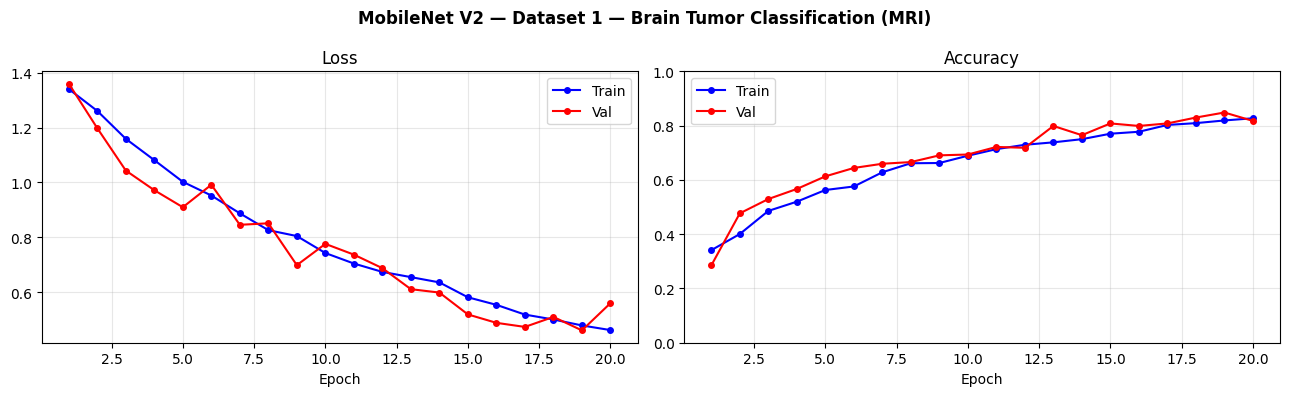

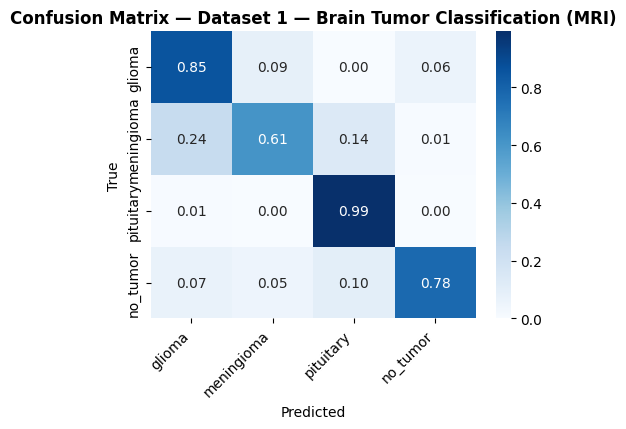

NameError: name 'model' is not defined

In [ ]:
# ── Generate & save plots  ─────────────────
for i, cfg in enumerate(DATASETS, start=1):
    name    = cfg['name']
    history = all_histories[name]
    results = all_results[name]

    print(f'\n── Plots: {name} ──')
    plot_curves(history, name,
                OUTPUT_DIR / f'efficientNet_b2_dataset{i}_curves.png')
    plot_confusion_matrix(results, cfg['class_names'], name,
                OUTPUT_DIR / f'efficientNet_b2_dataset{i}_confusion.png')

    # ── Overfitting summary plot ───────────────────────────────────────
    epochs = range(1, len(history['train_acc']) + 1)
    gaps   = [tr - vl for tr, vl in zip(history['train_acc'], history['val_acc'])]

    plt.figure(figsize=(8, 3))
    plt.plot(epochs, gaps, marker='o', color='crimson', linewidth=2)
    plt.axhline(y=15, color='orange', linestyle='--', label='Overfit threshold (15%)')
    plt.axhline(y=0,  color='green',  linestyle='--', label='Perfect generalization')
    plt.fill_between(epochs, gaps, 0,
                     where=[g > 0 for g in gaps], alpha=0.15, color='crimson')
    plt.title(f'Overfitting Gap Over Epochs — {name}')
    plt.xlabel('Epoch'); plt.ylabel('Train Acc − Val Acc (%)')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'efficientNet_b2_dataset{i}_gap.png', dpi=150)
    plt.show()

print('\n All plots saved!')


## 8. Results Summary

In [ ]:
import json

rows = [
    {
        'Dataset':       name,

        # hyperparameters
        'Model':         'EfficientNet B2 (untrained)',
        'Batch_Size':    BATCH_SIZE,
        'Epochs':        NUM_EPOCHS,
        'Learning_Rate': LEARNING_RATE,
        'Weight_Decay':  WEIGHT_DECAY,
        'Image_Size':    IMG_SIZE,
         # metrics
        'Accuracy':      f"{r['acc']:.4f}",
        'Precision':     f"{r['prec']:.4f}",
        'Recall':        f"{r['rec']:.4f}",
        'F1-Score':      f"{r['f1']:.4f}",
    }
    for name, r in all_results.items()
]

df = pd.DataFrame(rows, index=[f'Dataset {i+1}' for i in range(len(rows))])
print(df.to_string())
df.to_csv(OUTPUT_DIR / 'efficientnet_b2_results.csv')
print(f'\nSaved to {OUTPUT_DIR}/efficientnet_b2_results.csv')



#Save training accuracy

for name, history in all_histories.items():
    safe_name = name.replace(' ', '_').replace('—', '-')
    history_path = OUTPUT_DIR / f'{safe_name}_history.json'
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f'Saved history: {history_path}')

NameError: name 'all_results' is not defined